In [1]:
#Loading in Packages and Data

#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import pickle
import h5py
###############################################################
def coefs(coefficients,degree):
    coef=coefficients
    coefs=""
    for n in range(degree, -1, -1):
        string=f"({coefficients[len(coef)-(n+1)]:.1e})"
        coefs+=string + f"x^{n}"
        if n != 0:
            coefs+=" + "
    return coefs
###############################################################

# #Importing Model Data
    
# dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
# data=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_test7tundra-7_062217.nc') #***
# true_time=data['time']
# # parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_test5tundra-7_062217.nc') #***
# times=data['time'].values/(1e9 * 60); times=times.astype(float);
# Np_str='125e3'
# #Restricts the timesteps of the data from timesteps0 to 140
# data=data.isel(time=np.arange(0,140+1))
# # parcel=parcel.isel(time=np.arange(0,140+1))
# res='1km'

dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
data=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_1km_1e6.nc') #***
true_time=data['time']
parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_1km_1e6.nc') #***
times=data['time'].values/(1e9 * 60); times=times.astype(float);
Np_str='1e6'
#Restricts the timesteps of the data from timesteps0 to 140
res='1km'
job_array=False;index_adjust=0
ocean_fraction=0.25

# dx = 1km; Np = 50M
#Importing Model Data
check=False
dir2='/home/air673/koa_scratch/'
data=xr.open_dataset(dir2+'cm1out_1km_1min.nc') #***
parcel=xr.open_dataset(dir2+'cm1out_pdata_1km_1min_50M.nc') #***
res='1km'; t_res='1min'; Np_str='50e6'

# # dx = 1km; Np = 100M
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_1km_1min.nc') #***
# parcel=xr.open_dataset(dir2+'cm1out_pdata_1km_1min_100M.nc') #***
# res='1km'; t_res='1min'; Np_str='100e6'


# #uncomment if using 250m data
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_250m.nc') #***
# # # parcel=xr.open_dataset(dir2+'cm1out_pdata_250m.nc') #***

# # Restricts the timesteps of the data from timesteps0 to 140
# data=data.isel(time=np.arange(0,400+1))
# # # parcel=parcel.isel(time=np.arange(0,400+1))
# res='250m'

In [2]:
import sys
dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
path=dir2+'../Functions/'
sys.path.append(path)

import NumericalFunctions
from NumericalFunctions import * # import NumericalFunctions 
import PlottingFunctions
from PlottingFunctions import * # import PlottingFunctions


# # Get all functions in NumericalFunctions
# import inspect
# functions = [f[0] for f in inspect.getmembers(NumericalFunctions, inspect.isfunction)]
# functions

Top 10 objects with highest memory usage
{'initiate_array_2D': '0.0 MB', 'initiate_array_4D': '0.0 MB', 'Ddt': '0.0 MB', 'Ddz': '0.0 MB', 'Ddz_4DStretch': '0.0 MB', 'Ddy_4D': '0.0 MB', 'Ddx_4d': '0.0 MB', 'Ddz_3D': '0.0 MB', 'Ddy_3D': '0.0 MB', 'Ddx_3D': '0.0 MB'}

0.0 GB in use overall


In [3]:
def check_memory():
    import sys
    ipython_vars = ["In", "Out", "exit", "quit", "get_ipython", "ipython_vars"]
    print("Top 10 objects with highest memory usage")
    # Get a sorted list of the objects and their sizes
    mem = {
        key: round(value/1e6,2)
        for key, value in sorted(
            [
                (x, sys.getsizeof(globals().get(x)))
                for x in globals()
                if not x.startswith("_") and x not in sys.modules and x not in ipython_vars
            ],
            key=lambda x: x[1],
            reverse=True)[:10]
    }
    print({key:f"{value} MB" for key,value in mem.items()})
    print(f"\n{round(sum(mem.values()),2)/1000} GB in use overall")

In [4]:
# Reading Back Data Later
##############
def make_data_dict(var_names,read_type):
    if read_type=='h5py':
        with h5py.File(in_file, 'r') as f:
            data_dict = {var_name: f[var_name][:] for var_name in var_names}
            
    elif read_type=='xarray':
        in_data = xr.open_dataset(
            in_file,
            engine='h5netcdf',
            phony_dims='sort',
            chunks={'phony_dim_0': 100, 'phony_dim_1': 1_000_000} 
        )
        data_dict = {k: in_data[k][:].compute().data for k in var_names}
    return data_dict

# read_type='xarray'
read_type='h5py'

In [20]:
import h5py
dir2=dir+'Project_Algorithms/Lagrangian_Arrays/'
in_file=dir2+f'lagrangian_binary_array_{res}_{Np_str}_5min.h5'
# in_file=dir2+f'lagrangian_binary_array_{res}_{Np_str}_1min_50M.h5'

var_names = ['A_g', 'A_c', 'W', 'QCQI', 'Z', 'Y', 'X', 'z','x']
data_dict = make_data_dict(var_names,read_type)
A_g, A_c, W, QCQI, Z, Y, X, z, x = (data_dict[k] for k in var_names)

# #Making Time Matrix
# rows, cols = A.shape[0], A.shape[1]
# T = np.arange(rows).reshape(-1, 1) * np.ones((1, cols), dtype=int)
check_memory()

Top 10 objects with highest memory usage
{'A_g': '1064.0 MB', 'A_c': '1064.0 MB', 'Z': '1064.0 MB', 'Y': '1064.0 MB', 'X': '1064.0 MB', 'W': '532.0 MB', 'QCQI': '532.0 MB', 'parcel_z': '532.0 MB', 'z': '532.0 MB', 'x': '532.0 MB'}

7.98 GB in use overall


In [ ]:
################################################################################

In [ ]:
########################
#READING BACK IN
def LoadFinalData(in_file):
    dict = {}
    with h5py.File(in_file, 'r') as f:
        for key in f.keys():
            dict[key] = f[key][:]
    return dict

def LoadAllCloudBase():
    dir2 = dir + f'Project_Algorithms/Tracking_Algorithms/'
    in_file = dir2 + f"all_cloudbase_{res}_{t_res}_{Np_str}.pkl"
    with open(in_file, 'rb') as f:
        all_cloudbase = pickle.load(f)
    return(all_cloudbase)
min_all_cloudbase=np.nanmin(LoadAllCloudBase())
print(f"Minimum Cloudbase is: {min_all_cloudbase}\n")

dir2 = dir + f'Project_Algorithms/Tracking_Algorithms/'
in_file=dir2+f"parcel_tracking_SUBSET_{res}_{t_res}_{Np_str}"
final_dict=LoadFinalData(in_file)


#DYNAMICALLY CREATING VARIABLES
for key, value in final_dict.items():
    globals()[key] = value

# #DYNAMICALLY PRINTING VARIABLE SIZES
# for key in final_dict:
#     print(f"{key} has {final_dict[key].shape[0]} parcels")

#PRINTING VARIABLE SIZES (ONE BY ONE)
print(f'ALL: {len(ALL_out_arr)} CL parcels and {len(ALL_save_arr)} nonCL parcels')
print(f'SHALLOW: {len(SHALLOW_out_arr)} CL parcels and {len(SHALLOW_save_arr)} nonCL parcels')
print(f'DEEP: {len(DEEP_out_arr)} CL parcels and {len(DEEP_save_arr)} nonCL parcels')
print('\n')
print(f'ALL: {len(ALL_SBZ_out_arr)} SBZ parcels and {len(ALL_nonSBZ_out_arr)} nonSBZ parcels')
print(f'SHALLOW: {len(SHALLOW_SBZ_out_arr)} SBZ parcels and {len(SHALLOW_nonSBZ_out_arr)} nonSBZ parcels')
print(f'DEEP: {len(DEEP_SBZ_out_arr)} SBZ parcels and {len(DEEP_nonSBZ_out_arr)} nonSBZ parcels')
print('\n')
print(f'ALL: {len(ALL_ColdPool_out_arr)} ColdPool parcels')
print(f'SHALLOW: {len(SHALLOW_ColdPool_out_arr)} ColdPool parcels')
print(f'DEEP: {len(DEEP_ColdPool_out_arr)} ColdPool parcels')

#APPLYING JOB ARRAY
if "job_array" in globals():
    print('APPLYING JOB ARRAY')
    def job_filter(arr):
        return arr[(arr[:,0]>=start_job)&(arr[:,0]<end_job)]
    for name in [
        'ALL_out_arr', 'ALL_save_arr',
        'SHALLOW_out_arr', 'SHALLOW_save_arr',
        'DEEP_out_arr', 'DEEP_save_arr',
        'ALL_SBZ_out_arr', 'ALL_nonSBZ_out_arr',
        'SHALLOW_SBZ_out_arr', 'SHALLOW_nonSBZ_out_arr',
        'DEEP_SBZ_out_arr', 'DEEP_nonSBZ_out_arr',
        'ALL_ColdPool_out_arr', 'SHALLOW_ColdPool_out_arr', 'DEEP_ColdPool_out_arr'
    ]:
        globals()[name] = job_filter(globals()[name])

In [109]:
#ALL/DEEP/SHALLOW CL vs non-CL Tracked Parcel Plots
################################################################################

In [16]:
def averaged_profiles(profile): 
    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var
def averaged_profile_count(profile): 
    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    counts=out_var[:, 1]
    zlevels=out_var[:, 2]
    return counts,zlevels

(0.0, 16.894876628495247)

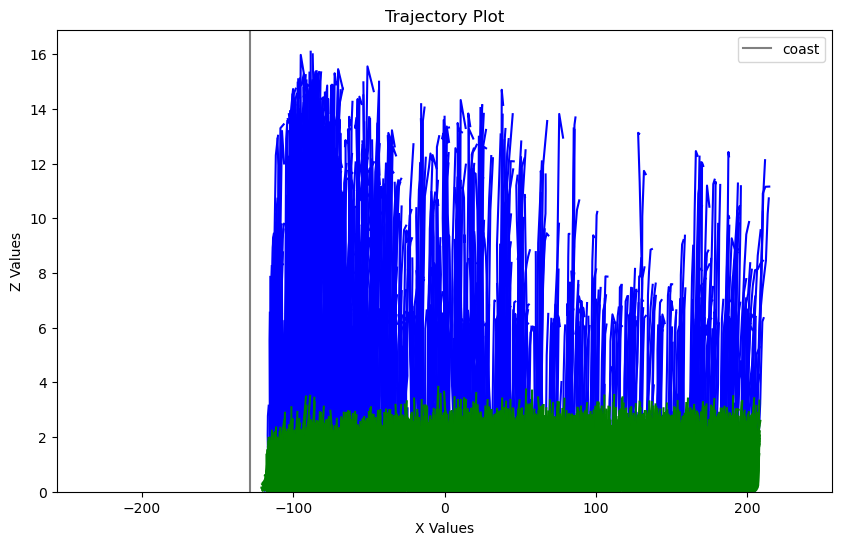

In [21]:
import matplotlib.pyplot as plt
import numpy as np

zhs = data['zh'].values
xhs = data['xh'].values

def CLTrajectoryPlot(ax, type):
    """
    Plot the trajectory based on the type with color corresponding to the type.
    
    Parameters:
    - ax: Matplotlib axes object to plot on.
    - type: Type of plot ('all', 'shallow', 'deep')
    """
    
    # Select the correct arrays based on type
    if type == 'all':
        out_arr = ALL_out_arr.copy()
        after_array = ALL_out_after_array
    elif type == 'shallow':
        out_arr = SHALLOW_out_arr.copy()
        after_array = SHALLOW_out_after_array
    elif type == 'deep':
        out_arr = DEEP_out_arr.copy()
        after_array = DEEP_out_after_array
    
    # Loop through each row of out_arr to plot
    for row in range(out_arr.shape[0]):
        after = after_array[row]
        p = out_arr[row, 0]
        
        ts_end = min(out_arr[row, 2] + 1 + after, len(data['time']))  # Ensure not exceeding the buffer
        ts = np.arange(out_arr[row, 1], ts_end)
        zs = Z[ts, p]  
        xs = X[ts, p]

        ###############################################################
        #THIS IS GRIDBOX zh (NOT AS ACCURATE)
        # z_values = zhs[zs]
        # x_values = xhs[xs]

        #USE THIS INSTEAD
        z_values = z[ts, p]/1000
        x_values = x[ts, p]/1000
        ###############################################################

        # Determine the color based on the 'type'
        if type == 'all':
            color = 'black'
        elif type == 'shallow':
            color = 'green'
        elif type == 'deep':
            color = 'blue'
        
        # Plot using ax.plot()
        ax.plot(x_values, z_values, color=color)


# Create a figure and axes outside the function
fig, ax = plt.subplots(figsize=(10, 6))  # You can adjust the size as needed

# Call the function with the 'deep' type and pass in the axes object (ax)
CLTrajectoryPlot(ax=ax, type='deep')
CLTrajectoryPlot(ax=ax, type='shallow')

# Optionally, add labels and title
ax.set_xlabel('X Values')
ax.set_ylabel('Z Values')
ax.set_title('Trajectory Plot')

#LABELS AND TITLES
ocean_fraction=2/8; coast=(xhs[-1]-xhs[0])*ocean_fraction; 
coast-=int(len(data['xh'])/2); ax.axvline(coast,color='grey',label='coast')
ax.legend()

ax.set_xlim(left=-int(len(data['xh'])/2),right=int(len(data['xh'])/2))
ax.set_ylim(bottom=0)#,top=10)


In [23]:
zhs = data['zh'].values
xhs = data['xh'].values
def CL_nonCL_dzdx_profile(type,type2):

    
    if type2=='CL':
        if type == 'all':
            out_arr = ALL_out_arr.copy()
            after_array = ALL_out_after_array
        elif type == 'shallow':
            out_arr = SHALLOW_out_arr.copy()
            after_array = SHALLOW_out_after_array
        elif type == 'deep':
            out_arr = DEEP_out_arr.copy()
            after_array = DEEP_out_after_array
    elif type2=='nonCL':
        if type == 'all':
            out_arr = ALL_save_arr.copy()
            after_array = ALL_save_after_array
        elif type == 'shallow':
            out_arr = SHALLOW_save_arr.copy()
            after_array = SHALLOW_save_after_array
        elif type == 'deep':
            out_arr = DEEP_save_arr.copy()
            after_array = DEEP_save_after_array
        

    
    zhs=data['zh'].values
    x_profile =np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
    x_profile[:,2]=zhs;
    
    for row in range(out_arr.shape[0]):
        after=after_array[row]
        # if np.mod(row,3000)==0: print(f'{row}/{out_arr.shape[0]}')
        p=out_arr[row,0]
        
        # ts=np.arange(out_arr[row,4],out_arr[row,5]+1 + after)
        ts_end = min(out_arr[row, 2] + 1 + after, len(data['time'])) #this takes care of exceeding buffers
        ts = np.arange(out_arr[row, 1], ts_end)
        
        zs=Z[ts,p]
        # ys=Y[ts,p]
        xs=X[ts,p]

        z_values = zhs[zs]
        x_values = xhs[xs]
        
        # vars=var_data[ts,p]
        np.add.at(x_profile[:, 0], zs, x_values)
        np.add.at(x_profile[:, 1], zs, 1)

    
    return x_profile

#CALCULATING
for type in ['all', 'shallow', 'deep']:
    globals()[f"{type}_CL_x_profile"] = CL_nonCL_dzdx_profile(type=type, type2='CL')
    globals()[f"{type}_CL_x_profile_avg"] = averaged_profiles(globals()[f"{type}_CL_x_profile"])

    globals()[f"{type}_nonCL_x_profile"] = CL_nonCL_dzdx_profile(type=type, type2='nonCL')
    globals()[f"{type}_nonCL_x_profile_avg"] = averaged_profiles(globals()[f"{type}_nonCL_x_profile"])


In [37]:
#SAVING

dir2=dir+'Project_Algorithms/Tracked_Profiles/'
output_file=dir2+f"CL_Tracked_Trajectories_{res}_{Np_str}_5min.h5"

# Create an HDF5 file to store the profiles
with h5py.File(output_file, "w") as h5f:
    for type in ['all', 'shallow', 'deep']:
        # Save CL profiles
        h5f.create_dataset(f"{type}_CL_x_profile", data=globals()[f"{type}_CL_x_profile"])
        # Save nonCL profiles
        h5f.create_dataset(f"{type}_nonCL_x_profile", data=globals()[f"{type}_nonCL_x_profile"])

In [ ]:
##################################################
#PLOTTING

In [39]:
import h5py

# Path to the file
input_file = dir + 'Project_Algorithms/Tracked_Profiles/' + f"CL_Tracked_Trajectories_{res}_{Np_str}_5min.h5"

# Dictionary to store the loaded profiles
loaded_profiles = {}

with h5py.File(input_file, "r") as h5f:
    for type in ['all', 'shallow', 'deep']:
        # Load CL profile
        loaded_profiles[f"{type}_CL_x_profile"] = h5f[f"{type}_CL_x_profile"][:]
        # Load nonCL profile
        loaded_profiles[f"{type}_nonCL_x_profile"] = h5f[f"{type}_nonCL_x_profile"][:]

Text(0.5, 1.0, 'Average Tracked CL vs nonCL Parcel Trajectories')

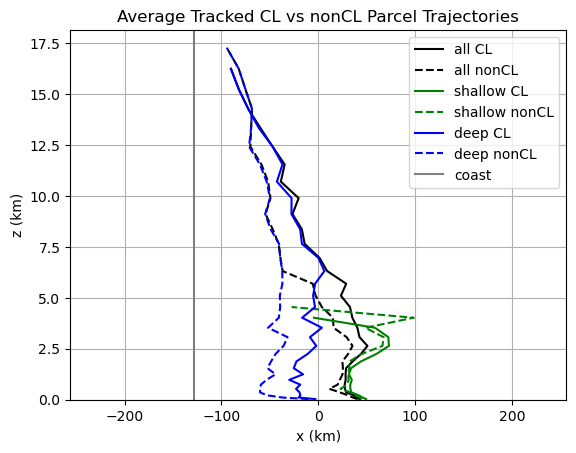

In [24]:
#PLOTTING
for type in ['all','shallow','deep']:

    # Accessing the dynamically created variables
    CL_x_profile_avg = globals()[f"{type}_CL_x_profile_avg"]
    nonCL_x_profile_avg = globals()[f"{type}_nonCL_x_profile_avg"]

    if type == 'all':
        color = 'black'
    elif type == 'shallow':
        color = 'green'
    elif type == 'deep':
        color = 'blue'
    plt.plot(CL_x_profile_avg[:,0], CL_x_profile_avg[:,1], color=color, label=type + " CL")
    plt.plot(nonCL_x_profile_avg[:,0], nonCL_x_profile_avg[:,1], linestyle='dashed', color=color, label=type + " nonCL")
    plt.xlim((0, xhs[-1]))



################################################################
#LABELS AND TITLES
ocean_fraction = 2/8
coast = (xhs[-1] - xhs[0]) * ocean_fraction
coast -= int(len(data['xh']) / 2)
plt.axvline(coast, color='grey', label='coast')
plt.legend()

# xhs = data['xh'].values - data['xh'][0].values; ax.set_xlim((xhs[0], xhs[-1]))
plt.xlim(left=-int(len(data['xh']) / 2), right=int(len(data['xh']) / 2))
plt.ylim(bottom=0)  # ,top=10)

plt.legend(loc='upper right')
plt.ylabel('z (km)')
plt.xlabel('x (km)')
plt.grid()
plt.title("Average Tracked CL vs nonCL Parcel Trajectories")


In [25]:
#SAME BUT FOR SBZ

In [29]:
def averaged_profiles(profile): 
    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var
def averaged_profile_count(profile): 
    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    counts=out_var[:, 1]
    zlevels=out_var[:, 2]
    return counts,zlevels

(0.0, 15.433443737612105)

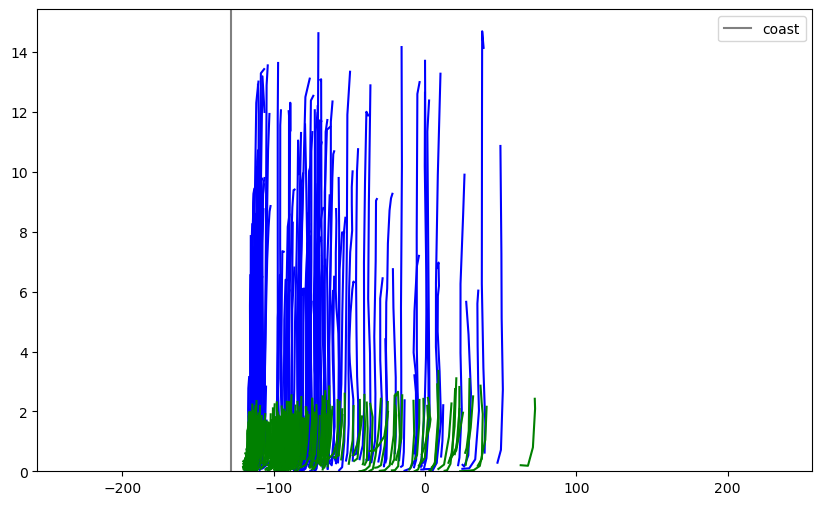

In [30]:
import matplotlib.pyplot as plt
import numpy as np

zhs = data['zh'].values
xhs = data['xh'].values

def SBZTrajectoryPlot(ax, type):
    """
    Plot the trajectory based on the type with color corresponding to the type.
    
    Parameters:
    - ax: Matplotlib axes object to plot on.
    - type: Type of plot ('all', 'shallow', 'deep')
    """

    
    # Select the correct arrays based on type
    if type == 'all':
        out_arr = ALL_SBZ_out_arr.copy()
        after_array = ALL_SBZ_out_after_array
    elif type == 'shallow':
        out_arr = SHALLOW_SBZ_out_arr.copy()
        after_array = SHALLOW_SBZ_out_after_array
    elif type == 'deep':
        out_arr = DEEP_SBZ_out_arr.copy()
        after_array = DEEP_SBZ_out_after_array
    
    # Loop through each row of out_arr to plot
    for row in range(out_arr.shape[0]):
        after = after_array[row]
        p = out_arr[row, 0]
        
        ts_end = min(out_arr[row, 2] + 1 + after, len(data['time']))  # Ensure not exceeding the buffer
        ts = np.arange(out_arr[row, 1], ts_end)
        zs = Z[ts, p-index_adjust] #JOBARRAY INDEX_ADJUST  
        xs = X[ts, p-index_adjust] #JOBARRAY INDEX_ADJUST
        
        ###############################################################
        #THIS IS GRIDBOX zh (NOT AS ACCURATE)
        # z_values = zhs[zs]
        # x_values = xhs[xs]

        #USE THIS INSTEAD
        z_values = z[ts, p]/1000
        x_values = x[ts, p]/1000
        ###############################################################

        # Determine the color based on the 'type'
        if type == 'all':
            color = 'black'
        elif type == 'shallow':
            color = 'green'
        elif type == 'deep':
            color = 'blue'
        
        # Plot using ax.plot()
        ax.plot(x_values, z_values, color=color)


    #COLORING BY HEIGHT
    #     # Plot each segment with color based on z_value
    #     for i in range(len(z_values) - 1):
    #         ax.plot(x_values[i:i+2], z_values[i:i+2], color=cmap(norm(z_values[i])))
    
    # # Create a ScalarMappable object for the colorbar
    # sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)

# Create a figure and axes outside the function
fig, ax = plt.subplots(figsize=(10, 6))  # You can adjust the size as needed

# Call the function with the 'deep' type and pass in the axes object (ax)
SBZTrajectoryPlot(ax=ax, type='deep')
SBZTrajectoryPlot(ax=ax, type='shallow')

#LABELS AND TITLES
ocean_fraction=2/8; coast=(xhs[-1]-xhs[0])*ocean_fraction; 
coast-=int(len(data['xh'])/2); ax.axvline(coast,color='grey',label='coast')
ax.legend()

# xhs = data['xh'].values-data['xh'][0].values; ax.set_xlim((xhs[0],xhs[-1]))
ax.set_xlim(left=-int(len(data['xh'])/2),right=int(len(data['xh'])/2))
ax.set_ylim(bottom=0)#,top=10)

In [43]:
zhs = data['zh'].values
xhs = data['xh'].values
def SBZ_nonSBZ_dzdx_profile(type,type2):

    if type2=='SBZ':
        if type == 'all':
            out_arr = ALL_SBZ_out_arr.copy()
            after_array = ALL_SBZ_out_after_array
        elif type == 'shallow':
            out_arr = SHALLOW_SBZ_out_arr.copy()
            after_array = SHALLOW_SBZ_out_after_array
        elif type == 'deep':
            out_arr = DEEP_SBZ_out_arr.copy()
            after_array = DEEP_SBZ_out_after_array
    elif type2=='nonSBZ':
        if type == 'all':
            out_arr = ALL_nonSBZ_out_arr.copy()
            after_array = ALL_nonSBZ_out_after_array
        elif type == 'shallow':
            out_arr = SHALLOW_nonSBZ_out_arr.copy()
            after_array = SHALLOW_nonSBZ_out_after_array
        elif type == 'deep':
            out_arr = DEEP_nonSBZ_out_arr.copy()
            after_array = DEEP_nonSBZ_out_after_array
        

    
    zhs=data['zh'].values
    x_profile =np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
    x_profile[:,2]=zhs;
    
    for row in range(out_arr.shape[0]):
        after=after_array[row]
        # if np.mod(row,3000)==0: print(f'{row}/{out_arr.shape[0]}')
        p=out_arr[row,0]
        
        # ts=np.arange(out_arr[row,4],out_arr[row,5]+1 + after)
        ts_end = min(out_arr[row, 2] + 1 + after, len(data['time'])) #this takes care of exceeding buffers
        ts = np.arange(out_arr[row, 1], ts_end)
        
        zs=Z[ts,p]
        # ys=Y[ts,p]
        xs=X[ts,p]

        z_values = zhs[zs]
        x_values = xhs[xs]
        
        # vars=var_data[ts,p]
        np.add.at(x_profile[:, 0], zs, x_values)
        np.add.at(x_profile[:, 1], zs, 1)

    
    return x_profile

#CALCULATING
for type in ['all', 'shallow', 'deep']:
    globals()[f"{type}_SBZ_x_profile"] = SBZ_nonSBZ_dzdx_profile(type=type, type2='SBZ')
    globals()[f"{type}_SBZ_x_profile_avg"] = averaged_profiles(globals()[f"{type}_SBZ_x_profile"])

    globals()[f"{type}_nonSBZ_x_profile"] = SBZ_nonSBZ_dzdx_profile(type=type, type2='nonSBZ')
    globals()[f"{type}_nonSBZ_x_profile_avg"] = averaged_profiles(globals()[f"{type}_nonSBZ_x_profile"])
print('done')

done


In [45]:
#SAVING

dir2 = dir + 'Project_Algorithms/Tracked_Profiles/'
output_file = dir2 + f"SBZ_Tracked_Trajectories_{res}_{Np_str}_5min.h5"

# Create an HDF5 file to store the profiles
with h5py.File(output_file, "w") as h5f:
    for type in ['all', 'shallow', 'deep']:
        # Save SBZ profiles
        h5f.create_dataset(f"{type}_SBZ_x_profile", data=globals()[f"{type}_SBZ_x_profile"])
        # Save nonSBZ profiles
        h5f.create_dataset(f"{type}_nonSBZ_x_profile", data=globals()[f"{type}_nonSBZ_x_profile"])
print('done')

done


In [ ]:
##################################################
#PLOTTING

In [46]:
import h5py

# Path to the file
input_file = dir + 'Project_Algorithms/Tracked_Profiles/' + f"SBZ_Tracked_Trajectories_{res}_{Np_str}_5min.h5"

# Dictionary to store the loaded profiles
loaded_profiles = {}

with h5py.File(input_file, "r") as h5f:
    for type in ['all', 'shallow', 'deep']:
        # Load SBZ profile
        loaded_profiles[f"{type}_SBZ_x_profile"] = h5f[f"{type}_SBZ_x_profile"][:]
        # Load nonSBZ profile
        loaded_profiles[f"{type}_nonSBZ_x_profile"] = h5f[f"{type}_nonSBZ_x_profile"][:]


Text(0.5, 1.0, 'Average Tracked SBZ vs nonSBZ Parcel Trajectories')

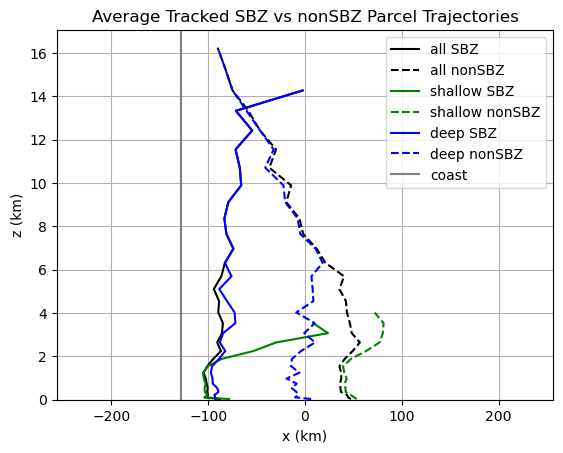

In [47]:
#PLOTTING
for type in ['all', 'shallow', 'deep']:

    # Accessing the dynamically created variables
    SBZ_x_profile_avg = globals()[f"{type}_SBZ_x_profile_avg"]
    nonSBZ_x_profile_avg = globals()[f"{type}_nonSBZ_x_profile_avg"]

    if type == 'all':
        color = 'black'
    elif type == 'shallow':
        color = 'green'
    elif type == 'deep':
        color = 'blue'
    plt.plot(SBZ_x_profile_avg[:, 0], SBZ_x_profile_avg[:, 1], color=color, label=type + " SBZ")
    plt.plot(nonSBZ_x_profile_avg[:, 0], nonSBZ_x_profile_avg[:, 1], linestyle='dashed', color=color, label=type + " nonSBZ")
    plt.xlim((0, xhs[-1]))



################################################################
#LABELS AND TITLES
ocean_fraction = 2/8
coast = (xhs[-1] - xhs[0]) * ocean_fraction
coast -= int(len(data['xh']) / 2)
plt.axvline(coast, color='grey', label='coast')
plt.legend()

# xhs = data['xh'].values - data['xh'][0].values; ax.set_xlim((xhs[0], xhs[-1]))
plt.xlim(left=-int(len(data['xh']) / 2), right=int(len(data['xh']) / 2))
plt.ylim(bottom=0)  # ,top=10)

plt.legend(loc='upper right')
plt.ylabel('z (km)')
plt.xlabel('x (km)')
plt.grid()
plt.title("Average Tracked SBZ vs nonSBZ Parcel Trajectories")


In [ ]:
#ColdPool
########################################################################################

In [33]:
def averaged_profiles(profile): 
    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var
def averaged_profile_count(profile): 
    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    counts=out_var[:, 1]
    zlevels=out_var[:, 2]
    return counts,zlevels

(0.0, 16.894876628495247)

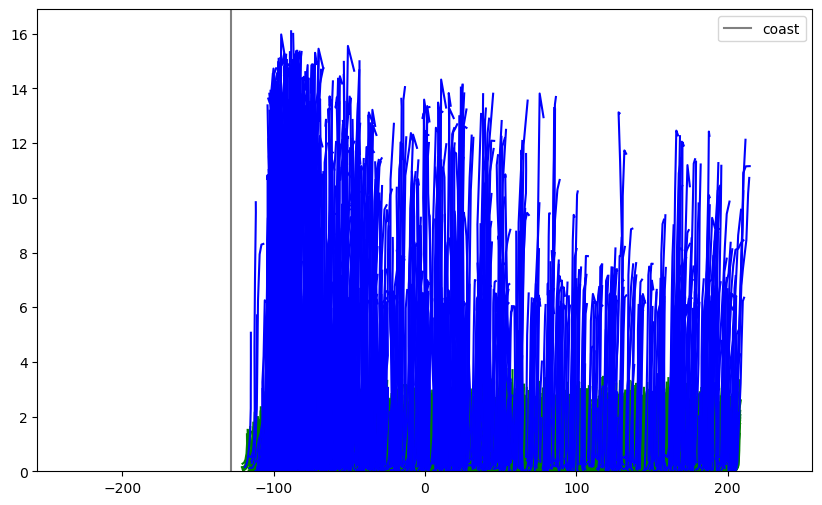

In [34]:
import matplotlib.pyplot as plt
import numpy as np

zhs = data['zh'].values
xhs = data['xh'].values

def ColdPoolTrajectoryPlot(ax, type):
    """
    Plot the trajectory based on the type with color corresponding to the type.
    
    Parameters:
    - ax: Matplotlib axes object to plot on.
    - type: Type of plot ('all', 'shallow', 'deep')
    """
    
    # Select the correct arrays based on type
    if type == 'all':
        out_arr = ALL_ColdPool_out_arr.copy()
        after_array = ALL_ColdPool_after_array
    elif type == 'shallow':
        out_arr = SHALLOW_ColdPool_out_arr.copy()
        after_array = SHALLOW_ColdPool_after_array
    elif type == 'deep':
        out_arr = DEEP_ColdPool_out_arr.copy()
        after_array = DEEP_ColdPool_after_array
    
    # Loop through each row of out_arr to plot
    for row in range(out_arr.shape[0]):
        after = after_array[row]
        p = out_arr[row, 0]
        
        ts_end = min(out_arr[row, 2] + 1 + after, len(data['time']))  # Ensure not exceeding the buffer
        ts = np.arange(out_arr[row, 1], ts_end)
        
        zs = Z[ts, p]  # Assuming Z and X are defined and hold the data
        xs = X[ts, p]
        
        ###############################################################
        #THIS IS GRIDBOX zh (NOT AS ACCURATE)
        # z_values = zhs[zs]
        # x_values = xhs[xs]

        #USE THIS INSTEAD
        z_values = z[ts, p]/1000
        x_values = x[ts, p]/1000
        ###############################################################

        # Determine the color based on the 'type'
        if type == 'all':
            color = 'black'
        elif type == 'shallow':
            color = 'green'
        elif type == 'deep':
            color = 'blue'
        
        # Plot using ax.plot()
        ax.plot(x_values, z_values, color=color)


    #COLORING BY HEIGHT
    #     # Plot each segment with color based on z_value
    #     for i in range(len(z_values) - 1):
    #         ax.plot(x_values[i:i+2], z_values[i:i+2], color=cmap(norm(z_values[i])))
    
    # # Create a ScalarMappable object for the colorbar
    # sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)

# Create a figure and axes outside the function
fig, ax = plt.subplots(figsize=(10, 6))  # You can adjust the size as needed

# Call the function with the 'deep' type and pass in the axes object (ax)
ColdPoolTrajectoryPlot(ax=ax, type='shallow')
ColdPoolTrajectoryPlot(ax=ax, type='deep')

#LABELS AND TITLES
ocean_fraction=2/8; coast=(xhs[-1]-xhs[0])*ocean_fraction; 
coast-=int(len(data['xh'])/2); ax.axvline(coast,color='grey',label='coast')
ax.legend()

# xhs = data['xh'].values-data['xh'][0].values; ax.set_xlim((xhs[0],xhs[-1]))
ax.set_xlim(left=-int(len(data['xh'])/2),right=int(len(data['xh'])/2))
ax.set_ylim(bottom=0)#,top=10)

In [49]:
zhs = data['zh'].values
xhs = data['xh'].values
def SBZ_ColdPool_dzdx_profile(type,type2):

    
    if type2=='SBZ':
        if type == 'all':
            out_arr = ALL_SBZ_out_arr.copy()
            after_array = ALL_SBZ_out_after_array
        elif type == 'shallow':
            out_arr = SHALLOW_SBZ_out_arr.copy()
            after_array = SHALLOW_SBZ_out_after_array
        elif type == 'deep':
            out_arr = DEEP_SBZ_out_arr.copy()
            after_array = DEEP_SBZ_out_after_array
    elif type2=='ColdPool':
        if type == 'all':
            out_arr = ALL_ColdPool_out_arr.copy()
            after_array = ALL_ColdPool_after_array
        elif type == 'shallow':
            out_arr = SHALLOW_ColdPool_out_arr.copy()
            after_array = SHALLOW_ColdPool_after_array
        elif type == 'deep':
            out_arr = DEEP_ColdPool_out_arr.copy()
            after_array = DEEP_ColdPool_after_array
        

    
    zhs=data['zh'].values
    x_profile =np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
    x_profile[:,2]=zhs;
    
    for row in range(out_arr.shape[0]):
        after=after_array[row]
        # if np.mod(row,3000)==0: print(f'{row}/{out_arr.shape[0]}')
        p=out_arr[row,0]
        
        # ts=np.arange(out_arr[row,4],out_arr[row,5]+1 + after)
        ts_end = min(out_arr[row, 2] + 1 + after, len(data['time'])) #this takes care of exceeding buffers
        ts = np.arange(out_arr[row, 1], ts_end)
        
        zs=Z[ts,p]
        # ys=Y[ts,p]
        xs=X[ts,p]

        z_values = zhs[zs]
        x_values = xhs[xs]
        
        # vars=var_data[ts,p]
        np.add.at(x_profile[:, 0], zs, x_values)
        np.add.at(x_profile[:, 1], zs, 1)

    
    return x_profile

#CALCULATING
for type in ['all', 'shallow', 'deep']:
    globals()[f"{type}_SBZ_x_profile"] = SBZ_ColdPool_dzdx_profile(type=type, type2='SBZ')
    globals()[f"{type}_SBZ_x_profile_avg"] = averaged_profiles(globals()[f"{type}_SBZ_x_profile"])

    globals()[f"{type}_ColdPool_x_profile"] = SBZ_ColdPool_dzdx_profile(type=type, type2='ColdPool')
    globals()[f"{type}_ColdPool_x_profile_avg"] = averaged_profiles(globals()[f"{type}_ColdPool_x_profile"])
print('done')

done


In [50]:
#SAVING

dir2 = dir + 'Project_Algorithms/Tracked_Profiles/'
output_file = dir2 + f"SBZ_Tracked_Trajectories_{res}_{Np_str}_5min.h5"

# Create an HDF5 file to store the profiles
with h5py.File(output_file, "w") as h5f:
    for type in ['all', 'shallow', 'deep']:
        # Save SBZ profiles
        h5f.create_dataset(f"{type}_SBZ_x_profile", data=globals()[f"{type}_SBZ_x_profile"])
        # Save ColdPool profiles
        h5f.create_dataset(f"{type}_ColdPool_x_profile", data=globals()[f"{type}_ColdPool_x_profile"])


In [ ]:
##################################################
#PLOTTING

In [51]:
import h5py

# Path to the file
input_file = dir + 'Project_Algorithms/Tracked_Profiles/' + f"SBZ_Tracked_Trajectories_{res}_{Np_str}_5min.h5"

# Dictionary to store the loaded profiles
loaded_profiles = {}

with h5py.File(input_file, "r") as h5f:
    for type in ['all', 'shallow', 'deep']:
        # Load SBZ profile
        loaded_profiles[f"{type}_SBZ_x_profile"] = h5f[f"{type}_SBZ_x_profile"][:]
        # Load ColdPool profile
        loaded_profiles[f"{type}_ColdPool_x_profile"] = h5f[f"{type}_ColdPool_x_profile"][:]


Text(0.5, 1.0, 'Average Tracked SBZ vs ColdPool Parcel Trajectories')

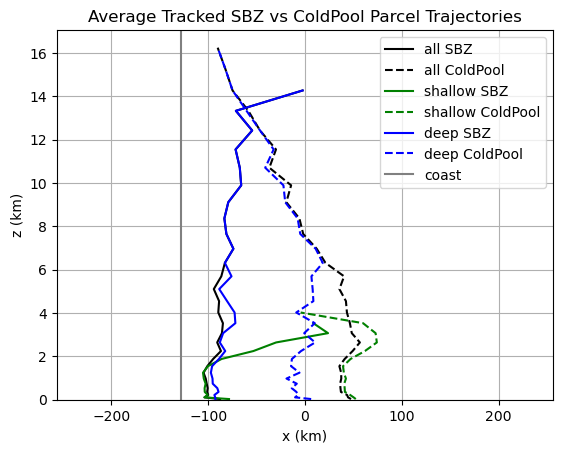

In [52]:
#PLOTTING
for type in ['all', 'shallow', 'deep']:

    # Accessing the dynamically created variables
    SBZ_x_profile_avg = globals()[f"{type}_SBZ_x_profile_avg"]
    ColdPool_x_profile_avg = globals()[f"{type}_ColdPool_x_profile_avg"]

    if type == 'all':
        color = 'black'
    elif type == 'shallow':
        color = 'green'
    elif type == 'deep':
        color = 'blue'
    plt.plot(SBZ_x_profile_avg[:, 0], SBZ_x_profile_avg[:, 1], color=color, label=type + " SBZ")
    plt.plot(ColdPool_x_profile_avg[:, 0], ColdPool_x_profile_avg[:, 1], linestyle='dashed', color=color, label=type + " ColdPool")
    plt.xlim((0, xhs[-1]))



################################################################
#LABELS AND TITLES
ocean_fraction = 2/8
coast = (xhs[-1] - xhs[0]) * ocean_fraction
coast -= int(len(data['xh']) / 2)
plt.axvline(coast, color='grey', label='coast')
plt.legend()

# xhs = data['xh'].values - data['xh'][0].values; ax.set_xlim((xhs[0], xhs[-1]))
plt.xlim(left=-int(len(data['xh']) / 2), right=int(len(data['xh']) / 2))
plt.ylim(bottom=0)  # ,top=10)

plt.legend(loc='upper right')
plt.ylabel('z (km)')
plt.xlabel('x (km)')
plt.grid()
plt.title("Average Tracked SBZ vs ColdPool Parcel Trajectories")
